## Optional Exercise 1

> all markdown with `$` is for rendering LaTeX for formulas

Initial $w$ and $w_0$ are $w=(1,0)$ and $w_0 = (-1)$

Use a learning rate of 0.01.

| y   | X    |
| --- | ---- |
| -1  | 2, 1 |
| -1  | 2, 2 |
| +1  | 4, 1 |
| +1  | 4, 2 |

1. Plot the data
2. Plot the hyperplane given by w and w0 - does this hyperplane separate the two classes?
3. Calculate least squares objective
4. Calculate the gradient
5. Update w and w0 with the gradient
6. Replot the hyperplane given by the new w and w0 - is the new hyperplane better than the previous?
7. Calculate the new least squares objective
8. Go to step 4 and repeat until 7


In [1]:
# install dependencies for graph plotting
%pip install matplotlib


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 1. Plot the data & 2. Plot the Hyperplane


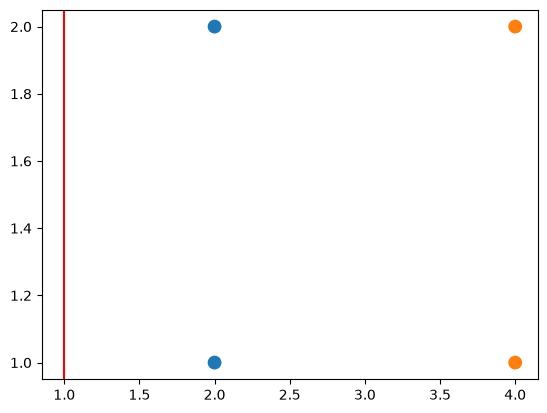

In [2]:
import math
import matplotlib.pyplot as plt

X = [[2, 1], [2, 2], [4, 1], [4, 2]]
y = [-1, -1, 1, 1]
w = [1, 0]
w0 = -1

# plot data
# unpack to make it x and y for plotting
px, py = zip(*X)

colors = ["tab:blue" if label == -1 else "tab:orange" for label in y]

plt.scatter(px, py, c=colors, s=80)

# hyperplane
plt.axvline(-w0 / w[0], color="red", label="hyperplane")
plt.show()

### 3. Least Square Objective

Formula for least square objective This is using LaTeX below, to make it easy to read.

$L = \sum_{i=0}^{n-1} (w^Tx_i + w_0 - y_i)^2$

Without `numpy` or `scikit`, we do the dot.product multiplication of all the data.


In [3]:
lso = []
sigma = 0
# traditional looping! we know length of X and y are same.

for i in range(len(X)):
    dot_product = 0
    row = X[i]
    for j in range(len(row)):
        dot_product += row[j] * w[j]

    sum = dot_product + w0 - y[i]
    lso.append(sum)
    sigma = sigma + (sum * sum)

print(lso)
print(sigma)

[2, 2, 2, 2]
16


### 4. Calculate the gradient

Gradient for 1st derivative w.r.t. $w$ and $w_0$

$f(w_1,w_0) = \sum_{i=0}^{n-1} (w^Tx_i+w_0-y_i)^2$

#### Compute $\Delta f = (df/dw_1, df/dw_2)$ and $df/dw_0$

First Derivative of
| $w_1$ |$w_2$ | $w_0$ |
|---|---|---|
| $df/dw_1=2\sum_{i=0}^{3}(w^Tx_i+w_0-y_i)x_{i0}$ | $df/dw_2=2\sum_{i=0}^{3}(w^Tx_i+w_0-y_i)x_{i1}$ | $df/dw_0=2\sum_{i=0}^{3}(w^Tx_i+w_0-y_i)$ |

In [ ]:
# gradient calculation

def calculate_gradient(X, y, w, row_i):   
    g_sum = 0
    for i in range(len(X)):
        dot_product = 0
        val = 0
        row = X[i]
        for j in range(len(row)):
            dot_product += row[j] * w[j]

        if row_i == -1:
            val = (dot_product + w0 - y[i])
        else:
            val = (dot_product + w0 - y[i]) * row[row_i]            
        g_sum = g_sum + val
        print(dot_product, " | ", w0, " | ", y[i], " | ", row[0], " | ", val)

    dw = 2 * g_sum
    print("sum: ", g_sum, " | dw:", dw)
    print("--------------------")
    return dw


dw1 = calculate_gradient(X, y, w, 0)
dw2 = calculate_gradient(X, y, w, 1)
dw0 = calculate_gradient(X, y, w, -1)

print("dw1: ", dw1, " | dw2: ", dw2, " | dw0: ", dw0)

2  |  -1  |  -1  |  2  |  4
2  |  -1  |  -1  |  2  |  4
4  |  -1  |  1  |  4  |  8
4  |  -1  |  1  |  4  |  8
sum:  24  | dw: 48
--------------------
2  |  -1  |  -1  |  2  |  2
2  |  -1  |  -1  |  2  |  4
4  |  -1  |  1  |  4  |  2
4  |  -1  |  1  |  4  |  4
sum:  12  | dw: 24
--------------------
2  |  -1  |  -1  |  2  |  2
2  |  -1  |  -1  |  2  |  2
4  |  -1  |  1  |  4  |  2
4  |  -1  |  1  |  4  |  2
sum:  8  | dw: 16
--------------------
dw1:  48  | dw2:  24  | dw0:  16


### 5. New $w$ and $w_0$ with the gradient

$w = w -\eta \Delta f$

$w_0 = w_0 -\eta df/dw_0$

$\eta = 0.1$

In [ ]:
n = 0.01
delta_f = [dw1, dw2]

n_delta_f = []
# n * delta_f 
for dwi in delta_f:
    n_delta_f.append(dwi*n)

new_w = 0

# brute force!!! ~ too late at night! 
w = [w[0] - n_delta_f[0], w[1] - n_delta_f[1]]

### ZZZzzz... 

Complete later, need to put a clean way to do this in traditional python with no extra libs